# Astropedia GLD100 (100 m/px) hillshade check (throwaway diagnostic, not a tracked notebook pair)

Companion to `stripe_debug.py`'s investigation of the ~950m/1200m crosshatch artifact traced to
Lunaserv's own 128 ppd DTM layer. Pulls the same real AOI directly from USGS Astropedia's flat-file
GLD100 distribution (`Lunar_LRO_WAC_GLD100_DTM_79S79N_100m_v1.1.tif`, verified genuine 100 m/px,
79N-79S coverage -- see `docs/history.md`'s dated entry) via GDAL's `/vsicurl/` range-requests (not
a full 10GB download), reprojects it into the same per-camera local Orthographic working grid as
everything else in this investigation, and computes a directly-comparable hillshade -- so the user
can look at the actual result rather than just the frequency-domain numbers already checked
(X@950m=-5.2dB, Y@1200m=+5.0dB -- the specific Lunaserv artifact isn't present, but the file's own
Int16 elevation quantization showed a *different*, near-Nyquist artifact at ~143-149m).

**Avoids re-fetching the AOI** if `scratch/astropedia_aoi.npy` (saved by the earlier probe,
`scratch/astropedia_probe.py`) already exists -- that pull took ~64s (a non-tiled, non-COG file, so
even a windowed read pulls full-width row strips) and this notebook has no reason to repeat it.

In [1]:
import dataclasses
import math

import matplotlib.pyplot as plt
import numpy as np
import rasterio
from matplotlib.colors import LightSource
from rasterio.transform import from_bounds as transform_from_bounds
from rasterio.warp import Resampling, reproject
from rasterio.windows import from_bounds as window_from_bounds

from trntest import camera as camera_mod
from trntest import illumination, lunaserv
from trntest.config import load_config

config = dataclasses.replace(
    load_config(),
    edr_volume="LROLRC_0041B",
    edr_subdir="ESM4",
    edr_doy="2019305",
    edr_product="M1327210646CE",
    cdr_volume="LROLRC_1041B",
    cdr_product="M1327210646CC",
    target_frame_index=94,
)
camera = camera_mod.build_camera(config)
center_lon, center_lat = camera.footprint_lonlat_deg["center"]
azimuth_deg, elevation_deg = illumination.sun_azimuth_elevation_deg(center_lon, center_lat, camera.et)
print(f"sun azimuth={azimuth_deg:.2f} deg, elevation={elevation_deg:.2f} deg")

sun azimuth=227.98 deg, elevation=41.85 deg


## Working grid: reuse `fetch_dem_and_ortho`'s bbox/resolution (cache hits, no new network cost)

Calling this again doesn't re-fetch anything over the network -- both the ortho and Lunaserv DEM
fetches go through `cache.fetch_lunaserv_getmap`'s on-disk cache, already populated by earlier runs
of `stripe_debug.py` against this exact camera/AOI.

In [2]:
lunaserv_result = lunaserv.fetch_dem_and_ortho(camera, config)
local_crs = f"+proj=ortho +lon_0={center_lon} +lat_0={center_lat} +R={config.moon_radius_m} +units=m +no_defs"
working_transform = transform_from_bounds(*lunaserv_result.bbox, lunaserv_result.width, lunaserv_result.height)

ROI center (lon,lat deg): (np.float64(169.52577312637044), np.float64(38.40441758271966)), bbox (local m): (-129708.18042974346, -129262.85620584518, 131339.50438772232, 131894.26693394702)
ROI size 2610x2612 px (~100.0 m/px)


## Load (or, only if missing, fetch) the Astropedia AOI

In [3]:
deg_bbox = lunaserv.pad_bbox(lunaserv.footprint_bbox_deg(camera.footprint_lonlat_deg), config.dem_padding_fraction)
minlon, minlat, maxlon, maxlat = deg_bbox

astropedia_url = "/vsicurl/https://planetarymaps.usgs.gov/mosaic/Lunar_LRO_WAC_GLD100_DTM_79S79N_100m_v1.1.tif"
astropedia_cache_path = config.scratch_dir / "astropedia_aoi.npy"

# Cheap (~1s, metadata only) regardless of cache hit -- gives the real source CRS/transform to build
# the AOI window's own transform from, without hardcoding those numbers as magic constants.
with rasterio.Env(GDAL_DISABLE_READDIR_ON_OPEN="EMPTY_DIR", CPL_VSIL_CURL_ALLOWED_EXTENSIONS=".tif"):
    with rasterio.open(astropedia_url) as src:
        src_crs = src.crs
        src_transform = src.transform
        src_nodata = src.nodata
        geo_crs = f"+proj=longlat +R={config.moon_radius_m} +no_defs"
        from rasterio.warp import transform_bounds

        left, bottom, right, top = transform_bounds(geo_crs, src_crs, minlon, minlat, maxlon, maxlat)
        window = window_from_bounds(left, bottom, right, top, transform=src_transform)
        window_transform = rasterio.windows.transform(window, src_transform)

        if astropedia_cache_path.exists():
            print(f"reusing cached AOI: {astropedia_cache_path}")
            astropedia_elevation = np.load(astropedia_cache_path)
        else:
            print("no cache found, fetching AOI via /vsicurl/ (real network read, ~1 min)...")
            astropedia_elevation = src.read(1, window=window)
            astropedia_cache_path.parent.mkdir(parents=True, exist_ok=True)
            np.save(astropedia_cache_path, astropedia_elevation)
            print(f"saved to {astropedia_cache_path}")

print(f"AOI shape: {astropedia_elevation.shape}, value range: {astropedia_elevation.min()} .. {astropedia_elevation.max()}")

reusing cached AOI: /workspace/scratch/astropedia_aoi.npy
AOI shape: (2610, 3339), value range: -2132 .. 4692


## Reproject into the same local Orthographic working grid, then hillshade

Astropedia's file is in an Equidistant Cylindrical ("Equirectangular") projection, standard
parallel 0 -- like the raw lon/lat native grid this whole investigation already dealt with, its
"100 m" pixels are only isotropic in real ground distance *at the equator*; away from it (as here,
~38.4N), east-west ground distance per pixel is smaller than north-south. Reproject into the same
per-camera local Orthographic grid as everything else (genuinely isotropic), the same way
`lunaserv.reproject_dem_to_local_grid` already does for Lunaserv's native fetch -- just with this
file's own CRS as the source.

In [4]:
reprojected_elevation = np.full((lunaserv_result.height, lunaserv_result.width), np.nan, dtype="float64")
reproject(
    source=astropedia_elevation,
    destination=reprojected_elevation,
    src_transform=window_transform,
    src_crs=src_crs,
    src_nodata=src_nodata,
    dst_transform=working_transform,
    dst_crs=local_crs,
    dst_nodata=np.nan,
    resampling=Resampling.bilinear,
)

astropedia_hillshade = LightSource(azdeg=azimuth_deg, altdeg=elevation_deg).hillshade(
    reprojected_elevation, dx=config.dem_target_gsd_m, dy=config.dem_target_gsd_m
)

## Side-by-side: current Lunaserv-based result vs. Astropedia-based result

Same zoomed-crop convention as `stripe_debug.py` (quarter-frame, centered) -- capped at 2 columns
per row so crosshatching stays resolvable at full res (see feedback on subplot width).

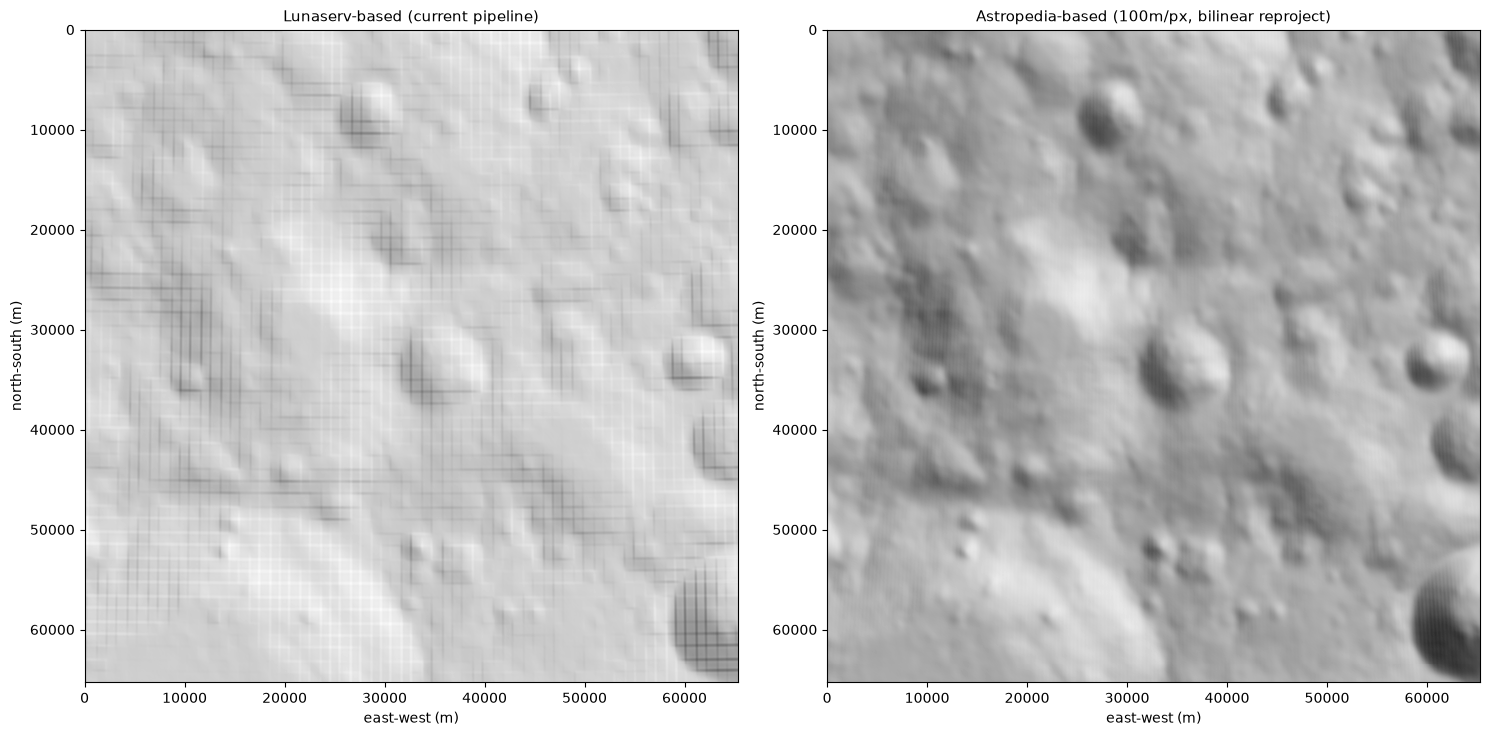

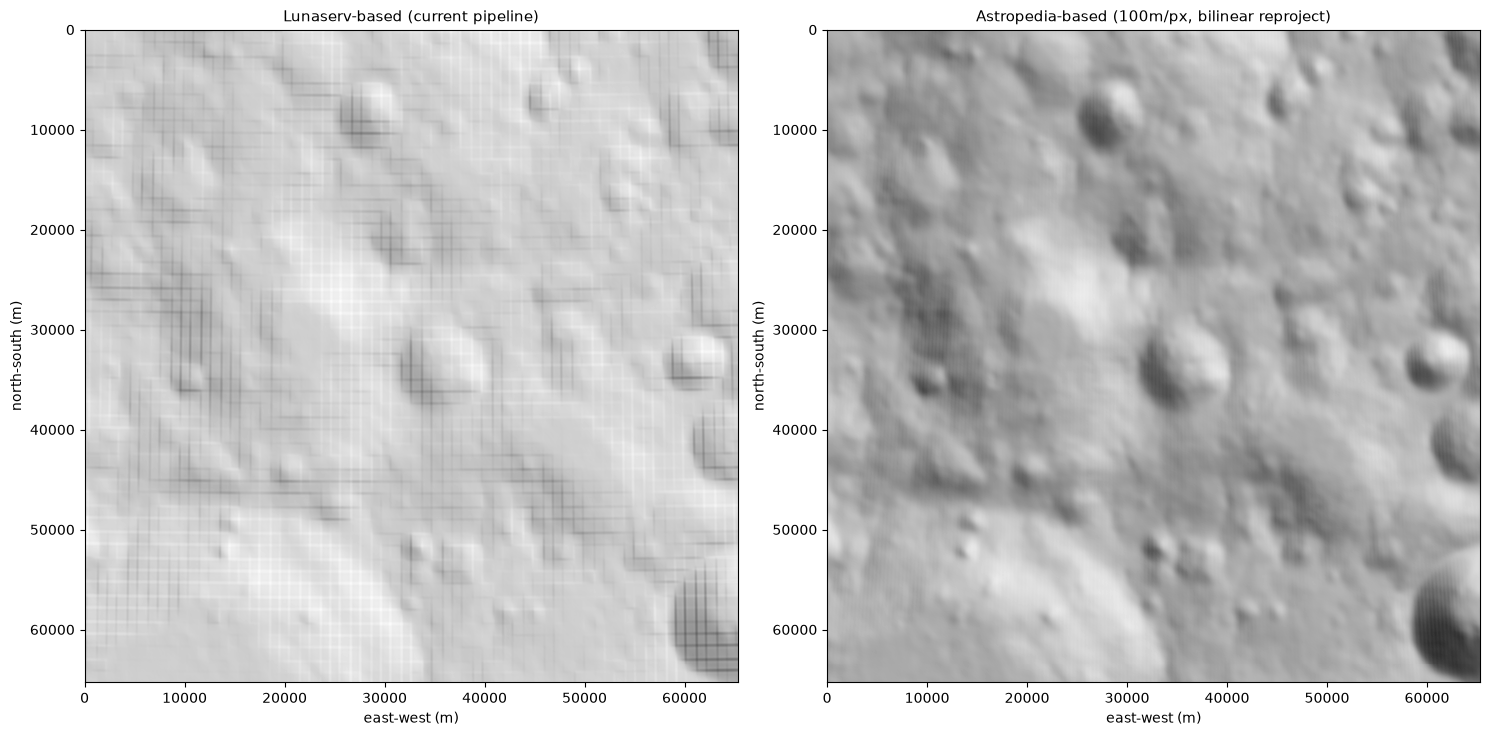

In [5]:
with rasterio.open(lunaserv_result.dem) as src:
    lunaserv_dem = src.read(1)
lunaserv_hillshade = LightSource(azdeg=azimuth_deg, altdeg=elevation_deg).hillshade(
    lunaserv_dem.astype(np.float64), dx=config.dem_target_gsd_m, dy=config.dem_target_gsd_m
)

h, w = lunaserv_hillshade.shape
y0, y1 = h * 3 // 8, h * 5 // 8
x0, x1 = w * 3 // 8, w * 5 // 8


def plot_crop_grid(images: dict, gsd_m: float, vmin=0.0, vmax=1.0, ncols: int = 2, cmap: str = "gray"):
    n = len(images)
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(7.5 * ncols, 7.5 * nrows), squeeze=False)
    for ax, (label, arr) in zip(axes.flat, images.items()):
        ah, aw = arr.shape
        extent = [0, aw * gsd_m, ah * gsd_m, 0]
        ax.imshow(arr, cmap=cmap, vmin=vmin, vmax=vmax, interpolation="nearest", extent=extent)
        ax.set_title(label, fontsize=11)
        ax.set_xlabel("east-west (m)")
        ax.set_ylabel("north-south (m)")
    for ax in list(axes.flat)[len(images) :]:
        ax.axis("off")
    fig.tight_layout()
    return fig


plot_crop_grid(
    {
        "Lunaserv-based (current pipeline)": lunaserv_hillshade[y0:y1, x0:x1],
        "Astropedia-based (100m/px, bilinear reproject)": astropedia_hillshade[y0:y1, x0:x1],
    },
    config.dem_target_gsd_m,
)

## Quantitative check, same method used throughout `stripe_debug.py`

[Lunaserv-based hillshade] frequency bins most above the fitted natural trend:
    freq=0.0141 cyc/px  period=  71.0 px (~    7104 m)  +  6.8 dB above trend
    freq=0.0076 cyc/px  period= 131.9 px (~   13193 m)  +  5.8 dB above trend
    freq=0.0097 cyc/px  period= 102.6 px (~   10261 m)  +  5.3 dB above trend
    freq=0.0119 cyc/px  period=  84.0 px (~    8395 m)  +  5.3 dB above trend
    freq=0.2047 cyc/px  period=   4.9 px (~     489 m)  +  5.2 dB above trend
[Astropedia-based hillshade] frequency bins most above the fitted natural trend:
    freq=0.2675 cyc/px  period=   3.7 px (~     374 m)  + 14.0 dB above trend
    freq=0.2870 cyc/px  period=   3.5 px (~     348 m)  + 14.0 dB above trend
    freq=0.2783 cyc/px  period=   3.6 px (~     359 m)  + 13.9 dB above trend
    freq=0.2826 cyc/px  period=   3.5 px (~     354 m)  + 13.7 dB above trend
    freq=0.2718 cyc/px  period=   3.7 px (~     368 m)  + 13.5 dB above trend


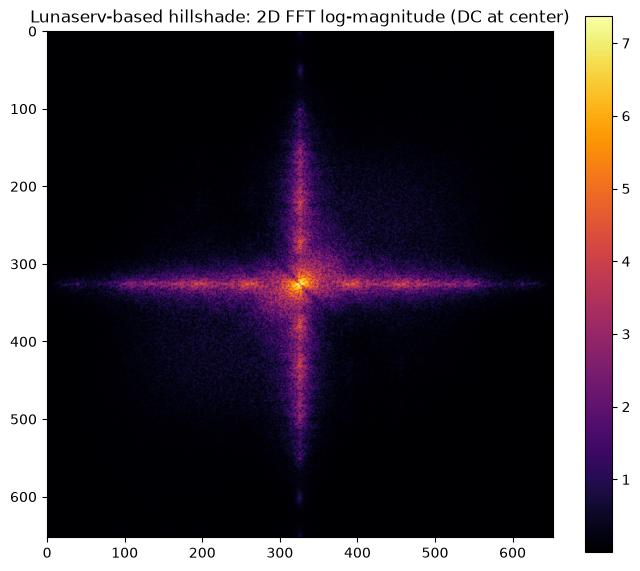

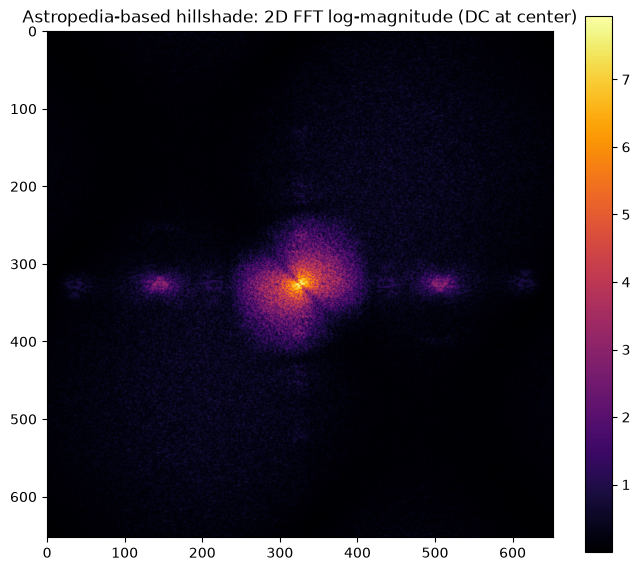

In [6]:
def periodicity_report(arr2d, gsd_m, label):
    crop = arr2d.astype(np.float64)
    crop = crop - crop.mean()
    window = np.outer(np.hanning(crop.shape[0]), np.hanning(crop.shape[1]))
    spectrum = np.fft.fftshift(np.fft.fft2(crop * window))
    magnitude = np.abs(spectrum)
    power = magnitude**2

    fig, ax = plt.subplots(figsize=(7, 7))
    im = ax.imshow(np.log1p(magnitude), cmap="inferno")
    ax.set_title(f"{label}: 2D FFT log-magnitude (DC at center)")
    fig.colorbar(im, ax=ax, shrink=0.8)
    fig.tight_layout()

    freqs_y = np.fft.fftshift(np.fft.fftfreq(crop.shape[0], d=1.0))
    freqs_x = np.fft.fftshift(np.fft.fftfreq(crop.shape[1], d=1.0))
    fy, fx = np.meshgrid(freqs_y, freqs_x, indexing="ij")
    freq_radius = np.sqrt(fy**2 + fx**2)

    n_radial_bins = crop.shape[0] // 2
    bin_edges = np.linspace(0, freq_radius.max(), n_radial_bins + 1)
    bin_idx = np.clip(np.digitize(freq_radius.ravel(), bin_edges) - 1, 0, n_radial_bins - 1)
    radial_power = np.array(
        [power.ravel()[bin_idx == i].mean() if np.any(bin_idx == i) else np.nan for i in range(n_radial_bins)]
    )
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    valid = np.isfinite(radial_power) & (bin_centers > 0) & (radial_power > 0)
    fit_range = valid & (bin_centers < 0.4 * freq_radius.max())
    log_f, log_p = np.log10(bin_centers[fit_range]), np.log10(radial_power[fit_range])
    slope, intercept = np.polyfit(log_f, log_p, 1)
    trend = 10 ** (intercept + slope * np.log10(bin_centers[valid]))
    residual_db = 10 * np.log10(radial_power[valid] / trend)
    valid_centers = bin_centers[valid]

    top_residual_idx = np.argsort(residual_db)[::-1][:5]
    print(f"[{label}] frequency bins most above the fitted natural trend:")
    for i in top_residual_idx:
        f = valid_centers[i]
        period_px = 1.0 / f if f > 0 else float("inf")
        print(f"    freq={f:.4f} cyc/px  period={period_px:6.1f} px (~{period_px * gsd_m:8.0f} m)  +{residual_db[i]:5.1f} dB above trend")


periodicity_report(lunaserv_hillshade[y0:y1, x0:x1], config.dem_target_gsd_m, "Lunaserv-based hillshade")
periodicity_report(astropedia_hillshade[y0:y1, x0:x1], config.dem_target_gsd_m, "Astropedia-based hillshade")